In [1]:
import copy
import bilby

from BilbyWrappers import (
    BilbyJointPrior,
    BilbyJointPriorDist,
    BilbyLikelihood
)


def sample_with_bilby(log_joint_prior, log_likelihood, draw_func,
                      scipy_stats_rng, specification, sampler):
    kwargs = copy.deepcopy(specification)

    if "parameter_order" not in kwargs:
        raise ValueError("Please provide parameter_order sampler option")
    parameter_order = kwargs["parameter_order"]
    del kwargs["parameter_order"]

    bilby_joint_dist = BilbyJointPriorDist(
        parameter_order, log_joint_prior.lpdf, log_joint_prior.rnd)
    bilby_prior = {key: BilbyJointPrior(bilby_joint_dist, key)
                    for key in parameter_order}

    bilby_likelihood = BilbyLikelihood(parameter_order, log_likelihood)

    result = bilby.run_sampler(
        likelihood=bilby_likelihood,
        priors=bilby_prior,
        sampler=sampler,
        **kwargs
    )

    return {"theta": result.samples}

In [2]:
import functools

import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

import surmise

# ----- SPECIFY MODEL'S PARAMETER SPACE
PARAMETER_ORDER = ["m", "b"]
M_IDX, B_IDX = (0, 1)
M_NAME = PARAMETER_ORDER[M_IDX]
B_NAME = PARAMETER_ORDER[B_IDX]
N_PARAMETERS = len(PARAMETER_ORDER)

# ----- SPECIFY CALIBRATOR
CALIBRATION_METHOD = "directbayes"

# ----- USER-PROVIDED BILBY-BASED SAMPLER
SAMPLER_METHOD = {
    "user": functools.partial(sample_with_bilby,
                              sampler="emcee")
}
SAMPLER_ARGS = {"sampler": SAMPLER_METHOD,
                "parameter_order": PARAMETER_ORDER,
                "clean": True}

# ----- LINEAR MODEL
# True parameter values
THETA_STAR = np.array([3.3, -0.4]).reshape(1, N_PARAMETERS)

def model(x, theta):
    f = np.zeros((theta.shape[0], len(x)))
    for k in range(0, theta.shape[0]):
        m = theta[k, M_IDX]
        b = theta[k, B_IDX]
        f[k, :] = m * x + b
    return f.T

# ----- EXPERIMENTAL DATASET
N_DATA = 10
SIGMA = 0.25
X_MIN, X_MAX = (0.0, 5.0)
X_DATA = np.linspace(X_MIN, X_MAX, N_DATA)
f_star = model(X_DATA, THETA_STAR)
#f_star = model(X_DATA, THETA_STAR_ARR)
F_DATA = f_star + np.random.normal(0.0, SIGMA, f_star.shape)
SIGMA_DATA = SIGMA * np.ones(N_DATA)

# ----- STATISTICAL MODEL
class joint_prior:
    def lpdf(theta):
        m_values = sps.uniform.logpdf(theta[:, M_IDX],  2.2, 2.2)
        b_values = sps.uniform.logpdf(theta[:, B_IDX], -3.3, 8.8)
        return (m_values + b_values).reshape((theta.shape[0], 1))

    def rnd(n):
        m_samples = sps.uniform.rvs( 2.2, 2.2, size=n)
        b_samples = sps.uniform.rvs(-3.3, 8.8, size=n)
        return np.vstack((m_samples, b_samples)).T

# ----- ESTHETICS
plt.style.use("ggplot")
FONTSIZE      = 12
TICK_FONTSIZE = FONTSIZE - 2
MARKERSIZE    = 5
LINEWIDTH     = 2.0

17:24 bilby INFO    : Running for label 'label', output will be saved to 'outdir'
17:24 bilby INFO    : Analysis priors:
17:24 bilby INFO    : m=BilbyWrappers.BilbyJointPrior(dist=User-provided joint prior distribution, name='m', latex_label='m', unit=None)
17:24 bilby INFO    : b=BilbyWrappers.BilbyJointPrior(dist=User-provided joint prior distribution, name='b', latex_label='b', unit=None)
17:24 bilby INFO    : Analysis likelihood class: <class 'BilbyWrappers.BilbyLikelihood'>
17:24 bilby INFO    : Analysis likelihood noise evidence: nan
17:24 bilby INFO    : Single likelihood evaluation took 7.875e-05 s
17:24 bilby INFO    : Using sampler Emcee with kwargs {'nwalkers': 500, 'a': 2, 'args': [], 'kwargs': {}, 'postargs': None, 'pool': None, 'live_dangerously': False, 'runtime_sortingfn': None, 'lnprob0': None, 'rstate0': None, 'blobs0': None, 'iterations': 100, 'thin': 1, 'storechain': True, 'mh_proposal': None}
17:24 bilby INFO    : Global meta data was removed from the result object


m^*              = 3.3
m posterior mean = 3.261361195683489
m posterior std  = 0.09792424643134061
b^*              = -0.4
b posterior mean = -0.4018749839094525
b posterior std  = 0.29358765323462876


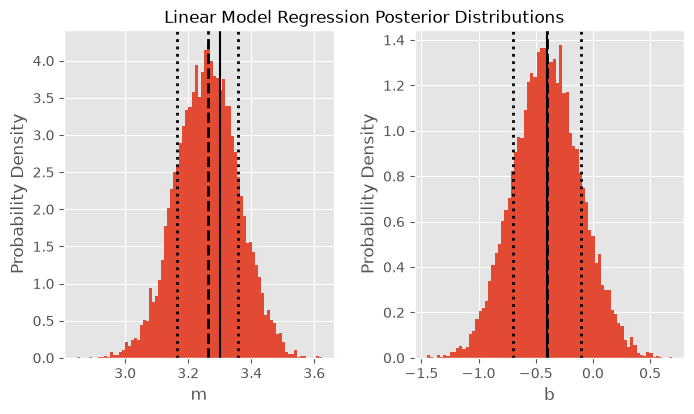

In [3]:
surmise.set_RNG(np.random.default_rng(123432))

emu = surmise.emulator(passthroughfunc=model)
calibrator = surmise.calibrator(
    method=CALIBRATION_METHOD,
    emu=emu,
    x=X_DATA, y=F_DATA, yvar=SIGMA_DATA,
    thetaprior=joint_prior,
    args=SAMPLER_ARGS
)

MC_theta_samples = calibrator.info["thetarnd"]

posterior_mean = calibrator.theta.mean()
m_posterior_mean = posterior_mean[M_IDX]
b_posterior_mean = posterior_mean[B_IDX]

posterior_std = np.sqrt(calibrator.theta.var())
m_posterior_std = posterior_std[M_IDX]
b_posterior_std = posterior_std[B_IDX]

print()
print(f"{M_NAME}^*              = {THETA_STAR[0, M_IDX]}")
print(f"{M_NAME} posterior mean = {m_posterior_mean}")
print(f"{M_NAME} posterior std  = {m_posterior_std}")
print(f"{B_NAME}^*              = {THETA_STAR[0, B_IDX]}")
print(f"{B_NAME} posterior mean = {b_posterior_mean}")
print(f"{B_NAME} posterior std  = {b_posterior_std}")

fig = plt.figure(1, figsize=(8, 4))
fig.suptitle("Linear Model Regression Posterior Distributions", fontsize=FONTSIZE)
fig.subplots_adjust(top=0.93, wspace=0.3)

subp = fig.add_subplot(121)
subp.hist(MC_theta_samples[:, M_IDX], bins='auto', density=True)
subp.axvline(THETA_STAR[0, M_IDX], color="black")
subp.axvline(m_posterior_mean, color="black",
             linestyle="--", linewidth=LINEWIDTH)
subp.axvline(m_posterior_mean - m_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.axvline(m_posterior_mean + m_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.set_xlabel(M_NAME, fontsize=FONTSIZE)
subp.set_ylabel("Probability Density", fontsize=FONTSIZE)
subp.grid(True)

subp = fig.add_subplot(122)
subp.hist(MC_theta_samples[:, B_IDX], bins='auto', density=True)
subp.axvline(THETA_STAR[0, B_IDX], color="black")
subp.axvline(b_posterior_mean, color="black",
             linestyle="--", linewidth=LINEWIDTH)
subp.axvline(b_posterior_mean - b_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.axvline(b_posterior_mean + b_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.set_xlabel(B_NAME, fontsize=FONTSIZE)
subp.set_ylabel("Probability Density", fontsize=FONTSIZE)
subp.grid(True)

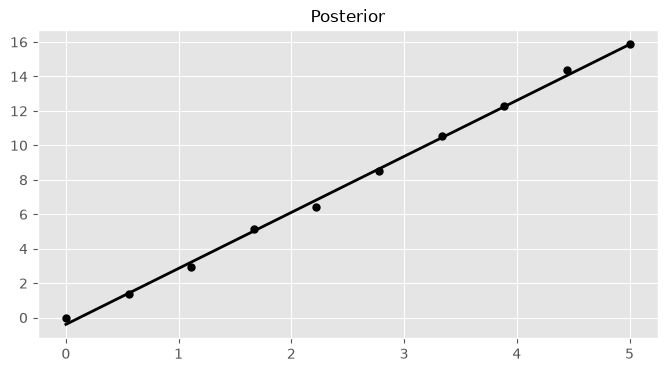

In [4]:
x_model = np.linspace(X_MIN, X_MAX, 100)

posterior_predict = emu(x_model, calibrator.theta.rnd(50))
posterior_predict_mean = np.mean(posterior_predict.mean(), axis=1)

fig = plt.figure(2, figsize=(8, 4))
subp = fig.add_subplot(111)
subp.set_title("Posterior", fontsize=FONTSIZE)
subp.plot(X_DATA, F_DATA, 'ok', markersize=MARKERSIZE)
subp.plot(x_model, posterior_predict_mean, 'k-', linewidth=LINEWIDTH)
subp.grid(True)